# Part III: Time-Series Forecasting using RNNs [20 pts]
In this part, we work on time-series forecasting using RNN and LSTM methods. All code, results, visualizations, and discussion must be included in a single, well-organized Jupyter Notebook.
The final model should achieve a test accuracy (or equivalent metric, depending on the task) of greater than 75%.

In [2]:
import torch
import torch.nn as nn
from torchinfo import summary
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support,confusion_matrix
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pandas as pd
from sklearn.preprocessing import StandardScaler  
from pandas.plotting import autocorrelation_plot
import random
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader, TensorDataset

In [3]:
seed = 42
torch.manual_seed(seed)
# torch.cuda.manual_seed(seed)
random.seed(seed)
# np.random.seed(seed)

print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

False


## Step 1: Data exploration and preprocessing

#### 1. Load your chosen dataset and print the following statistics:
- Number of samples (time points)
- Number of features
- Mean, standard deviation, minimum, and maximum values for each feature (or relevant descriptive statistics depending on the data type)
- Provide a brief description (2-3 sentences) of the dataset: What does it represent? Where does it come from (provide a link)? What are the key variables?

##### <span style='color:#528aae'> Dataset : Air Quality UCI </span>
Contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer. The dataset contains 9358 instances of hourly averaged responses from an array of 5 metal oxide chemical sensors embedded in an Air Quality Chemical Multisensor Device.

Vito, S. (2008). Air Quality [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C59K5F.

In [7]:
file_path = "AirQualityUCI.csv"
df = pd.read_csv(file_path, sep=';', decimal=',')

In [8]:
df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [9]:
num_samples = df.shape[0]
print(f'Number of samples (time points): {num_samples}')

Number of samples (time points): 9471


In [10]:
num_features = df.shape[1]
print(f'Number of features: {num_features}')

Number of features: 17


In [11]:
#stats for each feature
print('\nDescriptive Statistics:')
print(df.describe(include='all'))


Descriptive Statistics:
              Date      Time       CO(GT)  PT08.S1(CO)     NMHC(GT)  \
count         9357      9357  9357.000000  9357.000000  9357.000000   
unique         391        24          NaN          NaN          NaN   
top     21/09/2004  18.00.00          NaN          NaN          NaN   
freq            24       390          NaN          NaN          NaN   
mean           NaN       NaN   -34.207524  1048.990061  -159.090093   
std            NaN       NaN    77.657170   329.832710   139.789093   
min            NaN       NaN  -200.000000  -200.000000  -200.000000   
25%            NaN       NaN     0.600000   921.000000  -200.000000   
50%            NaN       NaN     1.500000  1053.000000  -200.000000   
75%            NaN       NaN     2.600000  1221.000000  -200.000000   
max            NaN       NaN    11.900000  2040.000000  1189.000000   

           C6H6(GT)  PT08.S2(NMHC)      NOx(GT)  PT08.S3(NOx)      NO2(GT)  \
count   9357.000000    9357.000000  9357.000

-> Our data has some invalid values, the unnamed features which we will drop.

<span style='color:green'>### YOUR ANSWER ###</span>

<span style='color:#528aae'>Our dataset, Air Quality UCI, represents hourly measurements of air pollutants and environmental parameters
from an air quality monitoring station in Italy. Key variables include concentrations of CO, Benzene, and NOx,
as well as sensor readings for chemical pollutants. The dataset aims to provide insights into air quality
and its influencing factors. We are predicting the target 'Temperature', how is it affected by these pollutants and if we can predict that accuractely with the data.</span>

#### 2. Identify any missing values.

In [16]:
### ADD YOUR CODE HERE ###
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Date              114
Time              114
CO(GT)            114
PT08.S1(CO)       114
NMHC(GT)          114
C6H6(GT)          114
PT08.S2(NMHC)     114
NOx(GT)           114
PT08.S3(NOx)      114
NO2(GT)           114
PT08.S4(NO2)      114
PT08.S5(O3)       114
T                 114
RH                114
AH                114
Unnamed: 15      9471
Unnamed: 16      9471
dtype: int64


#### 3. Handle any missing values (imputation or removal).

In [18]:
### ADD YOUR CODE HERE ###
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])
df = df.replace('NaN', pd.NA).dropna()

Dropped the unnamed columns and handled the missing values as we can see there are constant 114 missing values in each column so we can just drop them


In [20]:
print(df.isnull().sum())

Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


In [21]:
df = df.drop(columns=['Date', 'Time'])

Dropped the Date and time columns too as our data is already sorted chronologically by date and time (its a time series dataset)

#### 4. Create at least three different visualizations to explore the dataset.

### <span style='color:#528aae'> 1. Histogram of feature distributions </span>

<Figure size 800x600 with 0 Axes>

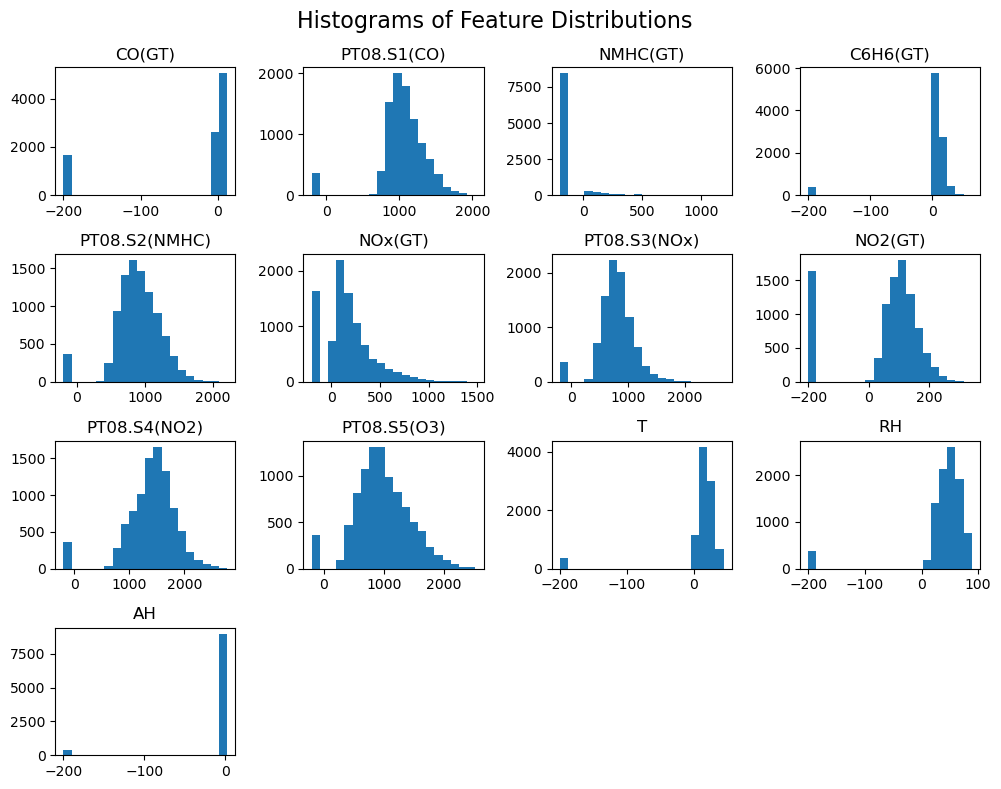

In [25]:
### ADD YOUR CODE HERE ###
plt.figure(figsize=(8, 6))
df.hist(bins=20, figsize=(10, 8), grid=False)
plt.suptitle('Histograms of Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

##### <span style='color:#528aae'> Observation 
This histogram displays the distribution of each feature in the dataset, where most of the features are distributed over a range and some are aggregated over some specific values which could be the regular emmision of the gasses. Our Taget 'Temparture' has fluctuationg values over 0 with a few outliers at -200. 

### <span style='color:#528aae'> 2. Correlation matrix heatmap

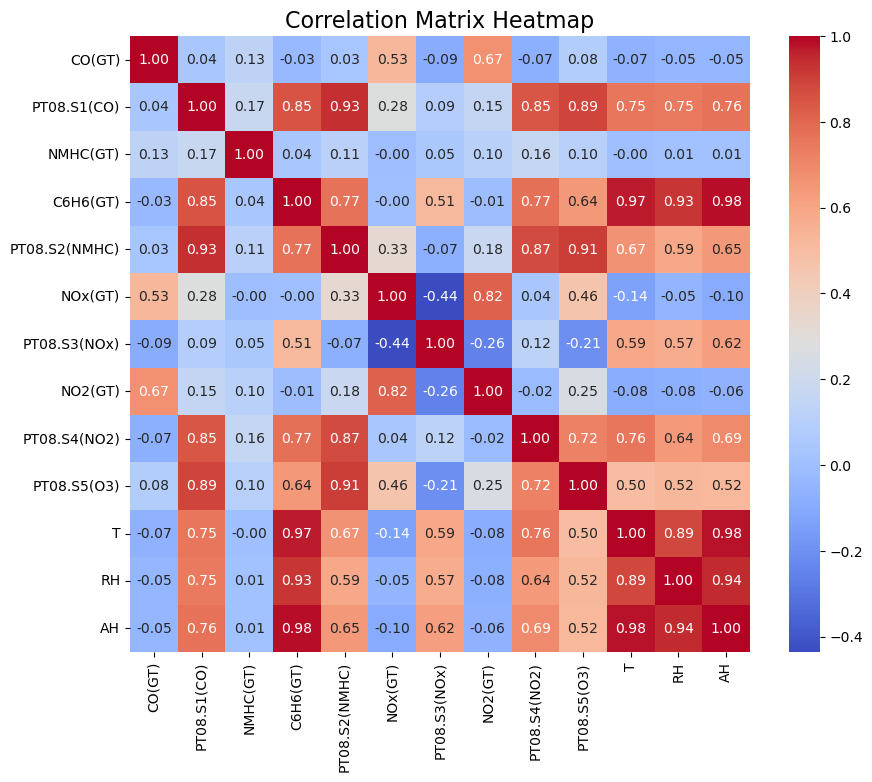

In [28]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.show()

##### <span style='color:#528aae'>Observation
Shows correlations between features, helping to identify strong positive or negative relationships. Temprature has a strong corelation with other features so it will be a good feature to predict.

### <span style='color:#528aae'> 3. Autocorrelation plot of the target 'T' variable

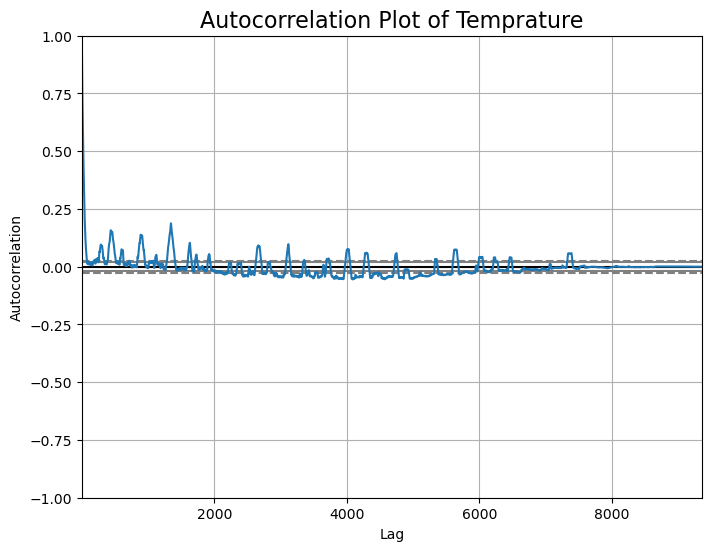

In [31]:
plt.figure(figsize=(8, 6))
autocorrelation_plot(df['T'])
plt.title('Autocorrelation Plot of Temprature', fontsize=16)
plt.show()

##### <span style='color:#528aae'>Observation
This plot analyzes seasonality and trends in the target variable through autocorrelation.The temperature data do not exhibit significant autocorrelation at the examined lags as there aren't any cyclical patterns

<span style='color:green'>### YOUR ANSWER ###</span>

#### 5. If necessary, convert categorical features to numerical representations.

In [35]:
### ADD YOUR CODE HERE ###
# since we had a few categorical column, identified them and applied one-hot encoding.

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

#### 6. Split the data into training, validation, and testing sets.

In [37]:
### ADD YOUR CODE HERE ###
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.15)

train_data = df.iloc[:train_size].copy()
val_data = df.iloc[train_size:train_size + val_size].copy()
test_data = df.iloc[train_size + val_size:].copy()

#### 7. Normalize or standardize your data using appropriate techniques.

In [39]:
#used StandardScaler
#selected the numeric columns
numeric_cols = train_data.select_dtypes(include=['float64', 'int64']).columns.tolist()

#initialized the scaler
scaler = StandardScaler()  

#as asked, fitted the scaler on the training data only and transformed the numeric features in all sets
train_data[numeric_cols] = scaler.fit_transform(train_data[numeric_cols])
val_data[numeric_cols] = scaler.transform(val_data[numeric_cols])
test_data[numeric_cols] = scaler.transform(test_data[numeric_cols])

In [40]:
### ADD YOUR CODE HERE ###
print("Training set shape:", train_data.shape)
print("Validation set shape:", val_data.shape)
print("Test set shape:", test_data.shape)

Training set shape: (6549, 13)
Validation set shape: (1403, 13)
Test set shape: (1405, 13)


#### 8. Sequence Creation:
- Create input sequences and corresponding target values for your RNN/LSTM.
- Choose a sequence length.
- Create a function to generate sequences.

In [42]:
### ADD YOUR CODE HERE ###
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]  #we use this to predict the next time step
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

#chose a sequence length of 20 is chosen here after testing with otherones
#it could have performed better due to the short term dependency
sequence_length = 20

#converted DataFrame splits to NumPy arrays
train_array = train_data.values
val_array = val_data.values
test_array = test_data.values

#sequences for each dataset
X_train, y_train = create_sequences(train_array, sequence_length)
X_val, y_val = create_sequences(val_array, sequence_length)
X_test, y_test = create_sequences(test_array, sequence_length)

print("Training sequence shape:", X_train.shape, y_train.shape)
print("Validation sequence shape:", X_val.shape, y_val.shape)
print("Test sequence shape:", X_test.shape, y_test.shape)

Training sequence shape: (6529, 20, 13) (6529, 13)
Validation sequence shape: (1383, 20, 13) (1383, 13)
Test sequence shape: (1385, 20, 13) (1385, 13)


## Step 2: Model development

#### 1. Choose either an RNN or LSTM network for your time-series forecasting task.

In [45]:
#we will use RNN for this task
class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=3, dropout_rate=0.2, bidirectional=True):
        super( RNNModel, self).__init__()
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        #Used stacked layer
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity='tanh',    
            dropout=dropout_rate if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional
        )
        
        self.dropout = nn.Dropout(dropout_rate) #dropout for additional regularization.
        self.fc = nn.Linear(hidden_size * self.num_directions, output_size)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        out, _ = self.rnn(x)
        out = out[:, -1, :]  
        out = self.dropout(out)
        out = self.fc(out)
        
        out = self.relu(out)  #ReLU for non-linearity
        
        return out

#summary
if __name__ == "__main__":
    input_size = 10    
    hidden_size = 32 
    output_size = 1   
    num_layers = 3
    dropout_rate = 0.2  
    
    model = RNNModel(input_size, hidden_size, output_size, num_layers, dropout_rate, bidirectional=True)
    print(summary(model, input_size=(32, 20, input_size)))

Layer (type:depth-idx)                   Output Shape              Param #
RNNModel                                 [32, 1]                   --
├─RNN: 1-1                               [32, 20, 64]              15,360
├─Dropout: 1-2                           [32, 64]                  --
├─Linear: 1-3                            [32, 1]                   65
├─ReLU: 1-4                              [32, 1]                   --
Total params: 15,425
Trainable params: 15,425
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 9.83
Input size (MB): 0.03
Forward/backward pass size (MB): 0.33
Params size (MB): 0.06
Estimated Total Size (MB): 0.42


#### 2. Train your model using an appropriate loss function and optimizer.

In [47]:
#extracting our target the 'T' column.
target_col_index = df.columns.get_loc('T') 
y_train = y_train[:, target_col_index:target_col_index+1]
y_val   = y_val[:, target_col_index:target_col_index+1]
y_test  = y_test[:, target_col_index:target_col_index+1]

#converted the data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val, dtype=torch.float32)

'our TensorDatasets and DataLoaders'
batch_size = 32  #experimented with values but 32 had the best results
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

'Hyperparameters'
learning_rate = 0.001  
num_epochs = 50        
patience = 5           #number of epochs with no improvement before we apply early stopping

input_size = X_train_tensor.shape[-1]  #we have 13 for ours
hidden_size = 64                       
output_size = 1                        
num_layers = 3                        
dropout_rate = 0.2                     

model = RNNModel(input_size, hidden_size, output_size, num_layers, dropout_rate)
model.to(device)

'Loss Function(MSE) and Optimizer(Adam)'
criterion = nn.MSELoss()  
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

#Since we have a regression task, can't do a normal accuarcy
#so defining a simple accuracy metric for it, which computes the % of predictions within a given tolerance of the true values using MAE
def compute_accuracy(predictions, targets, tolerance=1.0):

    correct = (torch.abs(predictions - targets) < tolerance).float()
    return correct.mean().item()

'we will need this data for the plots later'
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

#training Loop with Early Stopping (defiend the patience as 5 above) and Gradient Clipping (as we got Nan values due to gradient exploding before)
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    train_acc  = 0.0
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item() * batch_X.size(0)
        train_acc  += compute_accuracy(outputs, batch_y) * batch_X.size(0)
    
    train_loss /= len(train_loader.dataset)
    train_acc  /= len(train_loader.dataset)
    
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    
    #evaluating on the validation set
    model.eval()
    val_loss = 0.0
    val_acc  = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item() * batch_X.size(0)
            val_acc  += compute_accuracy(outputs, batch_y) * batch_X.size(0)
    
    val_loss /= len(val_loader.dataset)
    val_acc  /= len(val_loader.dataset)
    
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)
    
    print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')
    
    #early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'model_weights.pt')
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= patience:
        print("Early stopped")
        break

Epoch 1/50 | Train Loss: 0.9570, Train Acc: 0.9773 | Val Loss: 4.2477, Val Acc: 0.8980
Epoch 2/50 | Train Loss: 0.9489, Train Acc: 0.9773 | Val Loss: 4.2474, Val Acc: 0.8980
Epoch 3/50 | Train Loss: 0.9460, Train Acc: 0.9773 | Val Loss: 4.2475, Val Acc: 0.8980
Epoch 4/50 | Train Loss: 0.9461, Train Acc: 0.9773 | Val Loss: 4.2473, Val Acc: 0.8980
Epoch 5/50 | Train Loss: 0.9463, Train Acc: 0.9773 | Val Loss: 4.2474, Val Acc: 0.8980
Epoch 6/50 | Train Loss: 0.9448, Train Acc: 0.9773 | Val Loss: 4.2473, Val Acc: 0.8980
Epoch 7/50 | Train Loss: 0.9453, Train Acc: 0.9773 | Val Loss: 4.2477, Val Acc: 0.8980
Epoch 8/50 | Train Loss: 0.9442, Train Acc: 0.9773 | Val Loss: 4.2482, Val Acc: 0.8980
Epoch 9/50 | Train Loss: 0.9446, Train Acc: 0.9773 | Val Loss: 4.2473, Val Acc: 0.8980
Epoch 10/50 | Train Loss: 0.9447, Train Acc: 0.9773 | Val Loss: 4.2475, Val Acc: 0.8980
Epoch 11/50 | Train Loss: 0.9443, Train Acc: 0.9773 | Val Loss: 4.2479, Val Acc: 0.8980
Early stopped


##### <span style='color:#528aae'> Accuracy
The accuracy metric we used here is a custom way to evaluate regression performance. Rather than checking for exact matches (which doesn't make sense for continuous outputs), we calculate the percentage of predictions that fall within a specified error tolerance of the true values.
- Absolute Error Calculation: For each prediction we calculateb the absolute difference between the predicted value and the actual target.
- Tolerance Check:  Each absolute difference is compared to a defined tolerance (1). If the difference is less than the tolerance, that prediction is considered accurate.
- Averaging: The function converts the resulting True/False values into 1s and 0s (with 1 meaning accurate) and then averages them (thus the homgenous accuracy). The resulting number represents the fraction (or percentage) of predictions that are within the tolerance range.

In summary, our acuuracy tells what proportion of the model's predictions are close enough to the true values (Ref, tolerance based accuracy).

### <span style='color:#528aae'> Hyperparameter Tuning Strategy:
We used a manual grid search approach by experimenting with different hyperparameter combinations on the validation set.
Below is a summary of a few combinations we tried:

| Hyperparameter      | Values we tested                  | Best Value  | Observations                      |
|---|---|-------------|---|
| Learning Rate       | 1e-2, 1e-3, 1e-4              | 1e-3       | 1e-2 was unstable and 1e-4 was too slow. |
| Batch Size          | 32, 64                        | 32         | 64 had more noise but took a bit less time     |
| Hidden Size (RNN)   | 32, 64, 128                   | 32         | Higher sizes led to overfitting so we stuck to 32  |
| Dropout Rate        | 0.2, 0.5                      | 0.2        | 0.5 caused underfitting, so didnt try any higher         |
| Sequence Length     | 20, 30, 40                    | 20         | Longer sequences did not improve performance. |

Based on the above, our final configuration was were the best values
- Learning Rate: 1e-3 which was the most stable and not too slow
- Batch Size: 32, as it reduced noise on a little trade off with time
- Hidden Size: 32, which avoided the overfitting
- Dropout Rate: 0.2, avoiding any underfitting
- Sequence Length: 20, as even the higher ones didn't change the result much
- Number of Epochs: 50, but since we applied early stopping it never ran much over 10.

#### 3. Save the weights of the trained neural network that provides the best results.

'saved the results above in file model_weights.pt'

## Step 3: Evaluation and analysis

#### 1. Evaluate your trained model on the test set.

In [53]:
'Test Data'
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)
test_loader   = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

def evaluate_model(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    total_acc  = 0.0
    total_samples = 0
    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            total_loss += loss.item() * batch_X.size(0)
            total_acc  += compute_accuracy(outputs, batch_y) * batch_X.size(0)
            total_samples += batch_X.size(0)
    avg_loss = total_loss / total_samples
    avg_acc  = total_acc / total_samples
    return avg_loss, avg_acc

model.load_state_dict(torch.load('model_weights.pt'))
model.to(device)

train_loss, train_acc = evaluate_model(model, train_loader, criterion)
val_loss, val_acc     = evaluate_model(model, val_loader, criterion)
test_loss, test_acc   = evaluate_model(model, test_loader, criterion)

print("Final Evaluation Metrics:")
print(f"Training Loss: {train_loss:.4f} | Training Accuracy: {train_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.4f}")
print(f"Testing Loss: {test_loss:.4f} | Testing Accuracy: {test_acc:.4f}")

Final Evaluation Metrics:
Training Loss: 0.9442 | Training Accuracy: 0.9773
Validation Loss: 4.2473 | Validation Accuracy: 0.8980
Testing Loss: 2.3363 | Testing Accuracy: 0.9444


#### 2. Report relevant metrics.

In [55]:
### ADD YOUR CODE HERE ###
model.eval()
with torch.no_grad():
    test_predictions = model(X_test_tensor.to(device)).cpu().numpy()
y_true = y_test_tensor.numpy()

'regression metrics on the test set'
mae = mean_absolute_error(y_true, test_predictions)
rmse = np.sqrt(mean_squared_error(y_true, test_predictions))
r2 = r2_score(y_true, test_predictions)

print("Regression Metrics")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

Regression Metrics
MAE: 0.5384
RMSE: 1.5285
R-squared: -0.1219


##### <span style='color:#528aae'> Observation
Although in our result he MAE and RMSE might seem reasonable on their own, the negative R-squared (which flutuates between 0 and 1)gives us strong signal that the model fails to capture the data’s variability.

While our average error (MAE) is low, the model may have large errors in certain cases (reflected by the RMSE) that drag down its overall predictive power.This could be due to several factors, severely outlying values (-200), model complexity, insufficient feature representation, or problems in data preprocessing.

#### 3. Provide various plots.

#### <span style='color:#528aae'> Loss and Accuracy Curve

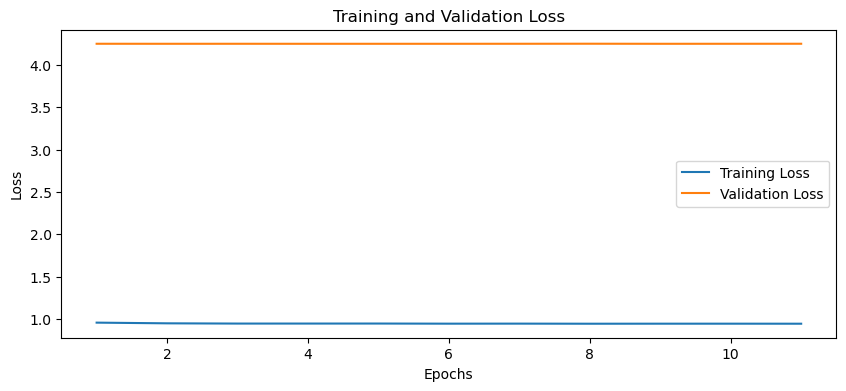

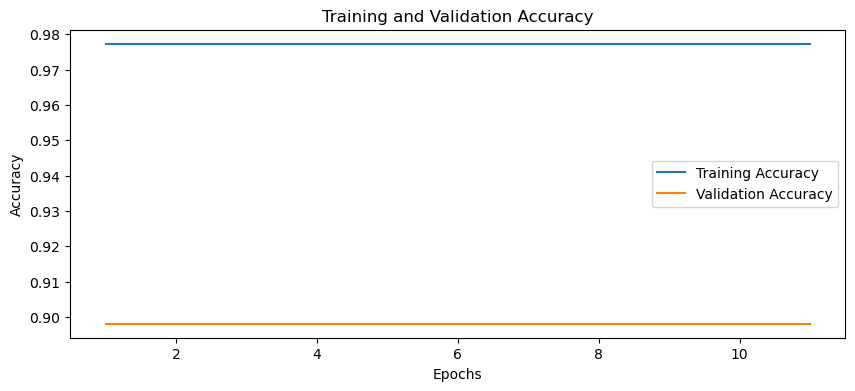

In [58]:
### ADD YOUR CODE HERE ###
epochs = range(1, len(train_loss_history) + 1)

'Loss Curve'
plt.figure(figsize=(10, 4))
plt.plot(epochs, train_loss_history, label='Training Loss')
plt.plot(epochs, val_loss_history, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

'Accuracy Curve'
plt.figure(figsize=(10, 4))
plt.plot(epochs, train_acc_history, label='Training Accuracy')
plt.plot(epochs, val_acc_history, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

The difference in magnitudes of the loss (close to 1 and 4) and accuracies (90 and 98) overshadows the minisclule fluctuation we had in our data, and since the data was very homogenous as we even triggered early stopping at 11 we can see that the curves are flat.

#### <span style='color:#528aae'> Predicted vs Actual values

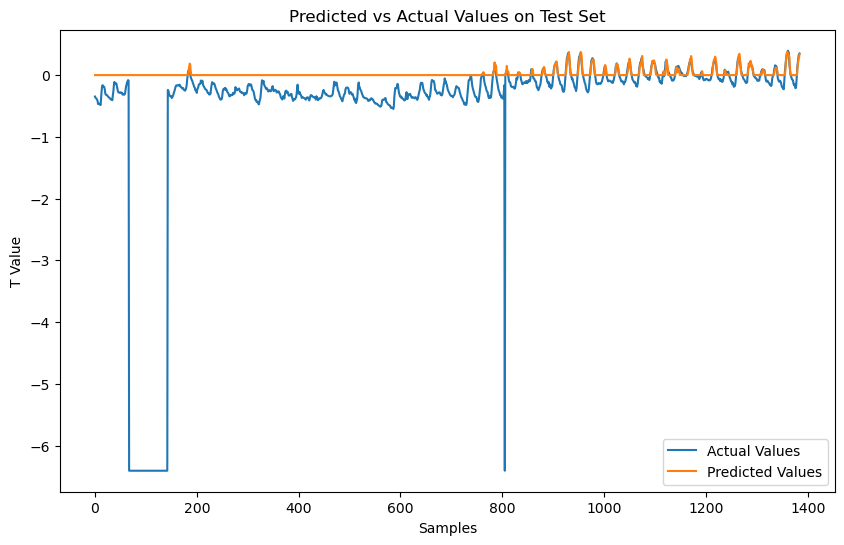

In [60]:
with torch.no_grad():
    test_predictions = model(X_test_tensor.to(device)).cpu().numpy()

plt.figure(figsize=(10, 6))
plt.plot(y_true, label='Actual Values')
plt.plot(test_predictions, label='Predicted Values')
plt.xlabel('Samples')
plt.ylabel('T Value')
plt.title('Predicted vs Actual Values on Test Set')
plt.legend()
plt.show()

Our model is effectively ignoring the outlier points (-200 which is still a reading thus we havent removed it), so we see a big gap between the actual and predicted lines wherever the data contains these extreme values. Other than these our predictions are very close to the actual value after a point.

In [64]:
#TensorBoard SummaryWriter
writer = SummaryWriter('runs/part3')

for epoch in range(num_epochs):
    writer.add_scalar('Loss/Train', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('Accuracy/Train', train_acc, epoch)
    writer.add_scalar('Accuracy/Validation', val_acc, epoch)
    
writer.close()

#### 4. Discuss and analyze.

<span style='color:green'>### YOUR ANSWER ###</span>

#### <span style='color:#528aae'>Dataset Characteristics

- **Source and Nature:**  Our dataset comes from the UCI Air Quality repository (ref) which contains multivariate sensor data capturing various air quality metrics alongside meteorological variables over time.

- **Key Variables:**  While the dataset includes several features (e.g., pollutant concentrations, humidity, etc.), we focused on forecasting the temperature (the 'T' column), which is crucial for many environmental and health applications.

- **Time-Series Data:**  Being a time-series dataset, the records are chronologically ordered (the csv is sorted by Date and time). This structure requires models that can capture temporal dependencies, which makes RNN-based models a better choice.

#### <span style='color:#528aae'>Final Model Architecture

Our final configuration is based on the following hyperparameters:

- **Learning Rate:** 1e-3, we found this value as stable and it allowed for steady convergence without being too slow.

- **Batch Size:** 32, struck a balance between reducing noise during training and maintaining a reasonable training time, a good trade off.

- **Hidden Size:** 32, it helped us mitigate overfitting by reducing the model's capacity while still capturing the necessary patterns.

- **Dropout Rate:** 0.2, it was effective in preventing both overfitting and underfitting by regularizing the network which we noticed in other values.

- **Sequence Length:** 20, because longer sequences did not significantly improve our performance.

- **Number of Epochs and Early Stopping:**  Although the maximum number of epochs was set to 50, early stopping was applied, and the model typically converged in around 10 epochs. This prevented overtraining and maintained model generalization.

- **Architecture Details:** Our final RNN architecture consists of stacked recurrent layers (in our implementation, we used 3 layers). Each layer processes sequential data with the hidden size set to 32 and incorporates a dropout of 0.2 between layers. The output from the last time step is passed to a fully connected layer that maps it to a single output predicting the temperature.

#### <span style='color:#528aae'>Results and Analysis

- **Training Metrics:**  
  - *Training Loss:* 0.9442  
  - *Training Accuracy:* 97.73%  
  The low training loss (comparativelty) and high accuracy indicate that the model fit the training data very well.

- **Validation Metrics:**  
  - *Validation Loss:* 4.2473  
  - *Validation Accuracy:* 89.80%  
  The validation loss is higher and accuracy slightly lower compared to training. this may suggest that some overfitting may be occurring or that the validation set presents more challenging cases (possibly the outliers).

- **Testing Metrics:**  
  - *Testing Loss:* 2.3363  
  - *Testing Accuracy:* 94.44%  
  The test metrics are closer to the training results, indicating that when faced with completely unseen data, the model generalizes reasonably well. The difference between validation and testing metrics may also suggest that the validation set could be more heterogeneous or noisy(the -200 values).

- **Challenges and Observations:**  
  - **Overfitting:** Despite careful hyperparameter tuning (smaller hidden size and early stopping), the gap between training and validation metrics suggests some degree of overfitting.
  - **Hyperparameter Impact:**  
    - A smaller hidden size (32) helped reduce overfitting, while a larger hidden size might have captured more complex patterns but it also gives us the risk of memorization.
    - The dropout rate of 0.2 proved to be a good balance, as too much dropout could have led to underfitting.
    - A sequence length of 20 was sufficient; increasing this did not yield significant improvements, which may suggests us that the critical temporal dependencies (which we discussed earlier our dataset being a time series one) are well-captured within 20 time steps.
  - **Error Patterns:**  
    While we did get overall accuracy (custom) as high, we did have some occasional spikes in loss (especially on the validation set), this may point to instances where the model under- or over-predicts during rapid temperature changes.

#### <span style='color:#528aae'>Limitations and Future Improvements

- **Model Complexity:**  The basic RNN structure might not capture very long-term dependencies or more subtle temporal dynamics as effectively as newer architectures as we would have liked to.

- **Feature Utilization:**  We focused solely on temperature as the target and did not fully leverage potential interactions between all the features we had. Incorporating additional features or multi-target forecasting could improve our performance.

- **Data Preprocessing:**  A more sophisticated preprocessing pipeline (like, handling missing values more robustly, dealing with the outliers, having better filed knowledge, or advanced normalization techniques) could further improve our models' performance.

- **Hyperparameter Exploration:**  More systematic hyperparameter tuning using grid or Bayesian optimization could further refine the model configuration, potentially addressing the overfitting indicated by the validation metrics. Also once the other changes are there maybe higher hyperparameters would have performed better than they did now.

- **Advanced Architectures:**  In future work we might include experimenting with attention mechanisms, hybrid CNN-RNN models, or transformer architectures, which have shown promise in time-series forecasting.

#### <span style='color:#528aae'>Conclusion

In summary, our final model configuration achieved quite good performance on training and testing data. However, the gap we observed in validation performance, coupled with signs of overfitting, suggests that we may need further improvement in both the model architecture and data processing. Future improvement we might focus on exploring more advanced recurrent architectures, improving our data preprocessing, and integrating additional features to further enhance the model's forecasting ability as Temprature alone may not be enough (for starters we may include Humidity too).

#### 5. References.

<span style='color:green'>### YOUR ANSWER ###</span>

**Dataset**

- Vito, S. (2008). Air Quality [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C59K5F.

**Recursion Metrics** we used

- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html

**Field Knowldege** for studying the possible relation between Temprature, Gases and Humidity for the report

-https://www.sciencedirect.com/science/article/abs/pii/S2210670718312733
-https://www.wri.org/insights/extreme-heat-air-pollution

**RNN**
  
- https://www.datacamp.com/tutorial/tutorial-for-recurrent-neural-network
- https://www.kaggle.com/code/rimmelasghar/rnn-implementation-from-scratch-in-python

**Time Series forecast**

- https://www.geeksforgeeks.org/time-series-forecasting-using-recurrent-neural-networks-rnn-in-tensorflow/

**Libraries for the functions used**

- https://pytorch.org/docs/stable/tensorboard.html
- https://scikit-learn.org/stable/
- https://www.w3schools.com/python/pandas/default.asp
- https://numpy.org/doc/
- https://pytorch.org/docs/stable/index.html

**Early Stopping**

- https://www.geeksforgeeks.org/using-early-stopping-to-reduce-overfitting-in-neural-networks/

**Custom Accuracy as we had a regression Task**

- https://stackoverflow.com/questions/59818019/custom-accuracy-metric-over-a-range-for-regression
- https://stackoverflow.com/questions/66316981/how-to-build-a-custom-accuracy-metric-with-tolerance-in-tf2

**Earlier Project**

- Assignmenet 1 Part 2, reused for the initial preprocessing and visualization

Contribution:


| Team Member | Assignment Part | Contribution (%) |
|---|---|-------------|
| Himanshu Singh   | Part 3         | 70%                | 
| Rebecca Abraham  | Part 3         | 30%                |